In [24]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# visualize missing values
import missingno as msno

# display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully")

Libraries loaded successfully


In [27]:
# ============================================
# DATASET PATH
# ============================================

DATA_PATH = r"C:\Users\Robin\OneDrive\Documents\Flight_Delay_Analytics\data\flights_sample_3m.csv"
print("Data path is created Successfully")

Data path is created Successfully


In [28]:
# ============================================
# LOAD DATASET
# ============================================

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

print("Dataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Dataset Shape: (3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0.0,NaN,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0.0,NaN,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0.0,NaN,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0.0,NaN,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0.0,NaN,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [29]:
# ============================================
# COLUMN LIST
# ============================================

df.columns

Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

| Column    | Meaning             |
| --------- | ------------------- |
| FL_DATE   | flight date         |
| AIRLINE   | airline name        |
| ORIGIN    | origin airport      |
| DEST      | destination airport |
| DEP_DELAY | departure delay     |
| ARR_DELAY | arrival delay       |
| DISTANCE  | flight distance     |


In [30]:
# ============================================
# DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

# Problems Visible From df.info()

Schema already reveals 3 issues.

Issue 1 — FL_DATE is object
FL_DATE object

Problem:

Dates stored as text, not datetime.

Fix:

In [31]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

# Issue 2 — Binary Columns as float

These should not be float.

CANCELLED float64
DIVERTED float64

Better type:

int
or
bool

Fix:

In [32]:
df["CANCELLED"] = df["CANCELLED"].astype(int)
df["DIVERTED"] = df["DIVERTED"].astype(int)

In [34]:
# ============================================
# MEMORY USAGE BEFORE OPTIMIZATION
# ============================================

memory_before = df.memory_usage(deep=True).sum() / 1024**2

print("Memory usage before optimization:", memory_before, "MB")

Memory usage before optimization: 1109.6299657821655 MB


# Memory Optimization Opportunity

Dataset uses:

1109.62 MB RAM

We can reduce memory by converting categorical variables.

# Identify Categorical Columns

These columns contain repeated string values.

Examples:

airlines

airports

city names




In [35]:
# ============================================
# FIND OBJECT COLUMNS
# ============================================

object_columns = df.select_dtypes(include="object").columns

print("Object columns:")
print(object_columns)

Object columns:
Index(['AIRLINE_DOT', 'ORIGIN_CITY', 'DEST_CITY'], dtype='object')


In [36]:
# ============================================
# CONVERT OBJECT → CATEGORY
# ============================================

for col in object_columns:
    df[col] = df[col].astype("category")

print("Conversion completed")

Conversion completed


categorical columns store values as integer codes

memory usage drops dramatically

# Optimize Numeric Columns

Some numeric columns also use more memory than needed.

For example:

float64 → float32
int64 → int32

Run:

In [37]:
# ============================================
# NUMERIC MEMORY OPTIMIZATION
# ============================================

float_cols = df.select_dtypes(include="float64").columns
int_cols = df.select_dtypes(include="int64").columns

df[float_cols] = df[float_cols].astype("float32")
df[int_cols] = df[int_cols].astype("int32")

print("Numeric optimization completed")

Numeric optimization completed


# Check Memory After Optimization

Now measure memory again.

In [38]:
# ============================================
# MEMORY USAGE AFTER OPTIMIZATION
# ============================================

memory_after = df.memory_usage(deep=True).sum() / 1024**2

print("Memory usage after optimization:", memory_after, "MB")

reduction = memory_before - memory_after

print("Memory reduced by:", reduction, "MB")

Memory usage after optimization: 320.55391693115234 MB
Memory reduced by: 789.0760488510132 MB


In [39]:
# ============================================
# VERIFY DATA TYPES
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int32         
 5   FL_NUMBER                int32         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int32         
 11  DEP_TIME                 float32       
 12  DEP_DELAY                float32       
 13  TAXI_OUT                 float32       
 14  WHEELS_OFF               float32       
 15  WHEELS_ON                float32       
 16  TAXI_IN                  float32       
 17  CRS_ARR_TIME             in

In [43]:
# ============================================
# SAVE MEMORY OPTIMIZED DATASET
# ============================================

import os
os.makedirs("data/processed", exist_ok=True)

optimized_path = "data/processed/flights_memory_optimized.csv"

df.to_csv(optimized_path, index=False)

print("Optimized dataset saved at:", optimized_path)

Optimized dataset saved at: data/processed/flights_memory_optimized.csv


In [44]:
# ============================================
# LOAD OPTIMIZED DATASET
# ============================================

DATA_PATH = "data/processed/flights_memory_optimized.csv"

df = pd.read_csv(DATA_PATH)

print("Optimized dataset loaded successfully")

print("Shape:", df.shape)

df.head()

Optimized dataset loaded successfully
Shape: (3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",1155,1151.0,-4.0,19.0,1210.0,1443.0,4.0,1501,1447.0,-14.0,0,NaN,0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",2120,2114.0,-6.0,9.0,2123.0,2232.0,38.0,2315,2310.0,-5.0,0,NaN,0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",954,1000.0,6.0,20.0,1020.0,1247.0,5.0,1252,1252.0,0.0,0,NaN,0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",1609,1608.0,-1.0,27.0,1635.0,1844.0,9.0,1829,1853.0,24.0,0,NaN,0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",1840,1838.0,-2.0,15.0,1853.0,2026.0,14.0,2041,2040.0,-1.0,0,NaN,0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


# Important Note About CSV

When we reload a CSV file:

- category types are lost

- everything becomes object again

To fix this we reassign categorical types.

# — Restore Categorical Columns

In [45]:
categorical_columns = [
    "AIRLINE",
    "AIRLINE_DOT",
    "AIRLINE_CODE",
    "ORIGIN",
    "ORIGIN_CITY",
    "DEST",
    "DEST_CITY",
    "CANCELLATION_CODE"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

print("Categorical columns restored")

Categorical columns restored


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype   
---  ------                   -----   
 0   FL_DATE                  object  
 1   AIRLINE                  category
 2   AIRLINE_DOT              category
 3   AIRLINE_CODE             category
 4   DOT_CODE                 int64   
 5   FL_NUMBER                int64   
 6   ORIGIN                   category
 7   ORIGIN_CITY              category
 8   DEST                     category
 9   DEST_CITY                category
 10  CRS_DEP_TIME             int64   
 11  DEP_TIME                 float64 
 12  DEP_DELAY                float64 
 13  TAXI_OUT                 float64 
 14  WHEELS_OFF               float64 
 15  WHEELS_ON                float64 
 16  TAXI_IN                  float64 
 17  CRS_ARR_TIME             int64   
 18  ARR_TIME                 float64 
 19  ARR_DELAY                float64 
 20  CANCELLED               

In [47]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float64       
 13  TAXI_OUT                 float64       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float64       
 17  CRS_ARR_TIME             in

In [49]:
# ============================================
# MISSING VALUE COUNT
# ============================================

missing_count = df.isnull().sum().sort_values(ascending=False)

print("Missing Value Count:")
print(missing_count)

Missing Value Count:
CANCELLATION_CODE          2920860
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_WEATHER          2466137
DELAY_DUE_CARRIER          2466137
AIR_TIME                     86198
ELAPSED_TIME                 86198
ARR_DELAY                    86198
WHEELS_ON                    79944
TAXI_IN                      79944
ARR_TIME                     79942
TAXI_OUT                     78806
WHEELS_OFF                   78806
DEP_DELAY                    77644
DEP_TIME                     77615
CRS_ELAPSED_TIME                14
ORIGIN_CITY                      0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
DISTANCE                         0
ORIGIN                           0
DEST                             0
DIVERTED                         0
CANCELLED                        0
DEST_CITY                        0

In [50]:
# ============================================
# MISSING VALUE PERCENTAGE
# ============================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage.sort_values(ascending=False)

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
CANCELLATION_CODE          97.362000
DELAY_DUE_LATE_AIRCRAFT    82.204567
DELAY_DUE_SECURITY         82.204567
DELAY_DUE_NAS              82.204567
DELAY_DUE_WEATHER          82.204567
DELAY_DUE_CARRIER          82.204567
AIR_TIME                    2.873267
ELAPSED_TIME                2.873267
ARR_DELAY                   2.873267
WHEELS_ON                   2.664800
TAXI_IN                     2.664800
ARR_TIME                    2.664733
TAXI_OUT                    2.626867
WHEELS_OFF                  2.626867
DEP_DELAY                   2.588133
DEP_TIME                    2.587167
CRS_ELAPSED_TIME            0.000467
ORIGIN_CITY                 0.000000
AIRLINE_DOT                 0.000000
AIRLINE_CODE                0.000000
DOT_CODE                    0.000000
FL_NUMBER                   0.000000
DISTANCE                    0.000000
ORIGIN                      0.000000
DEST                        0.000000
DIVERTED                    0.000000
CANCELLED   

In [51]:
# ============================================
# CREATE MISSING VALUE REPORT
# ============================================

missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percent": (df.isnull().sum()/len(df))*100
})

missing_report = missing_report.sort_values(
    by="Missing_Percent",
    ascending=False
)

print(missing_report)

                         Missing_Count  Missing_Percent
CANCELLATION_CODE              2920860        97.362000
DELAY_DUE_LATE_AIRCRAFT        2466137        82.204567
DELAY_DUE_SECURITY             2466137        82.204567
DELAY_DUE_NAS                  2466137        82.204567
DELAY_DUE_WEATHER              2466137        82.204567
DELAY_DUE_CARRIER              2466137        82.204567
AIR_TIME                         86198         2.873267
ELAPSED_TIME                     86198         2.873267
ARR_DELAY                        86198         2.873267
WHEELS_ON                        79944         2.664800
TAXI_IN                          79944         2.664800
ARR_TIME                         79942         2.664733
TAXI_OUT                         78806         2.626867
WHEELS_OFF                       78806         2.626867
DEP_DELAY                        77644         2.588133
DEP_TIME                         77615         2.587167
CRS_ELAPSED_TIME                    14         0

In [52]:
missing_report.to_csv("reports/missing_value_report.csv")

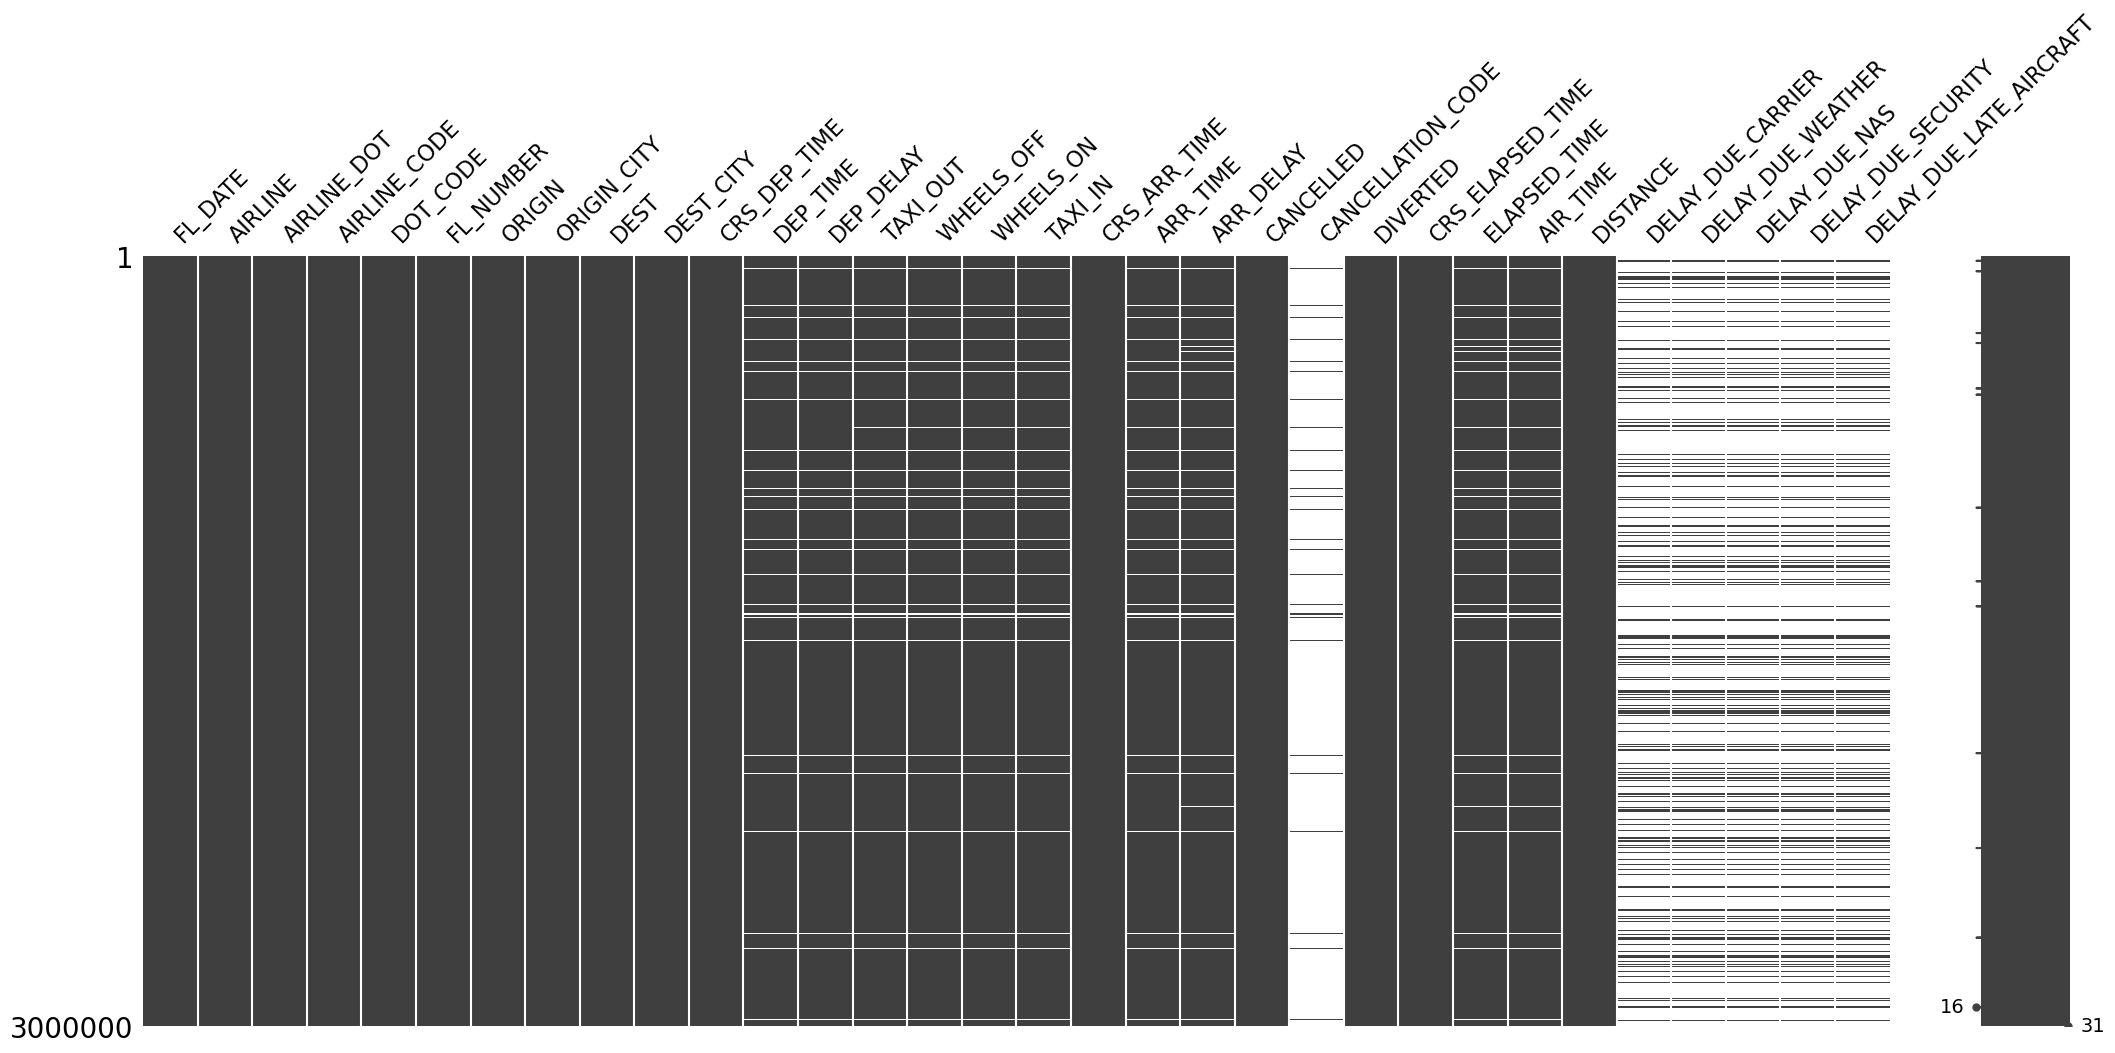

In [53]:
# ============================================
# MISSING DATA MATRIX
# ============================================

msno.matrix(df)
plt.show()

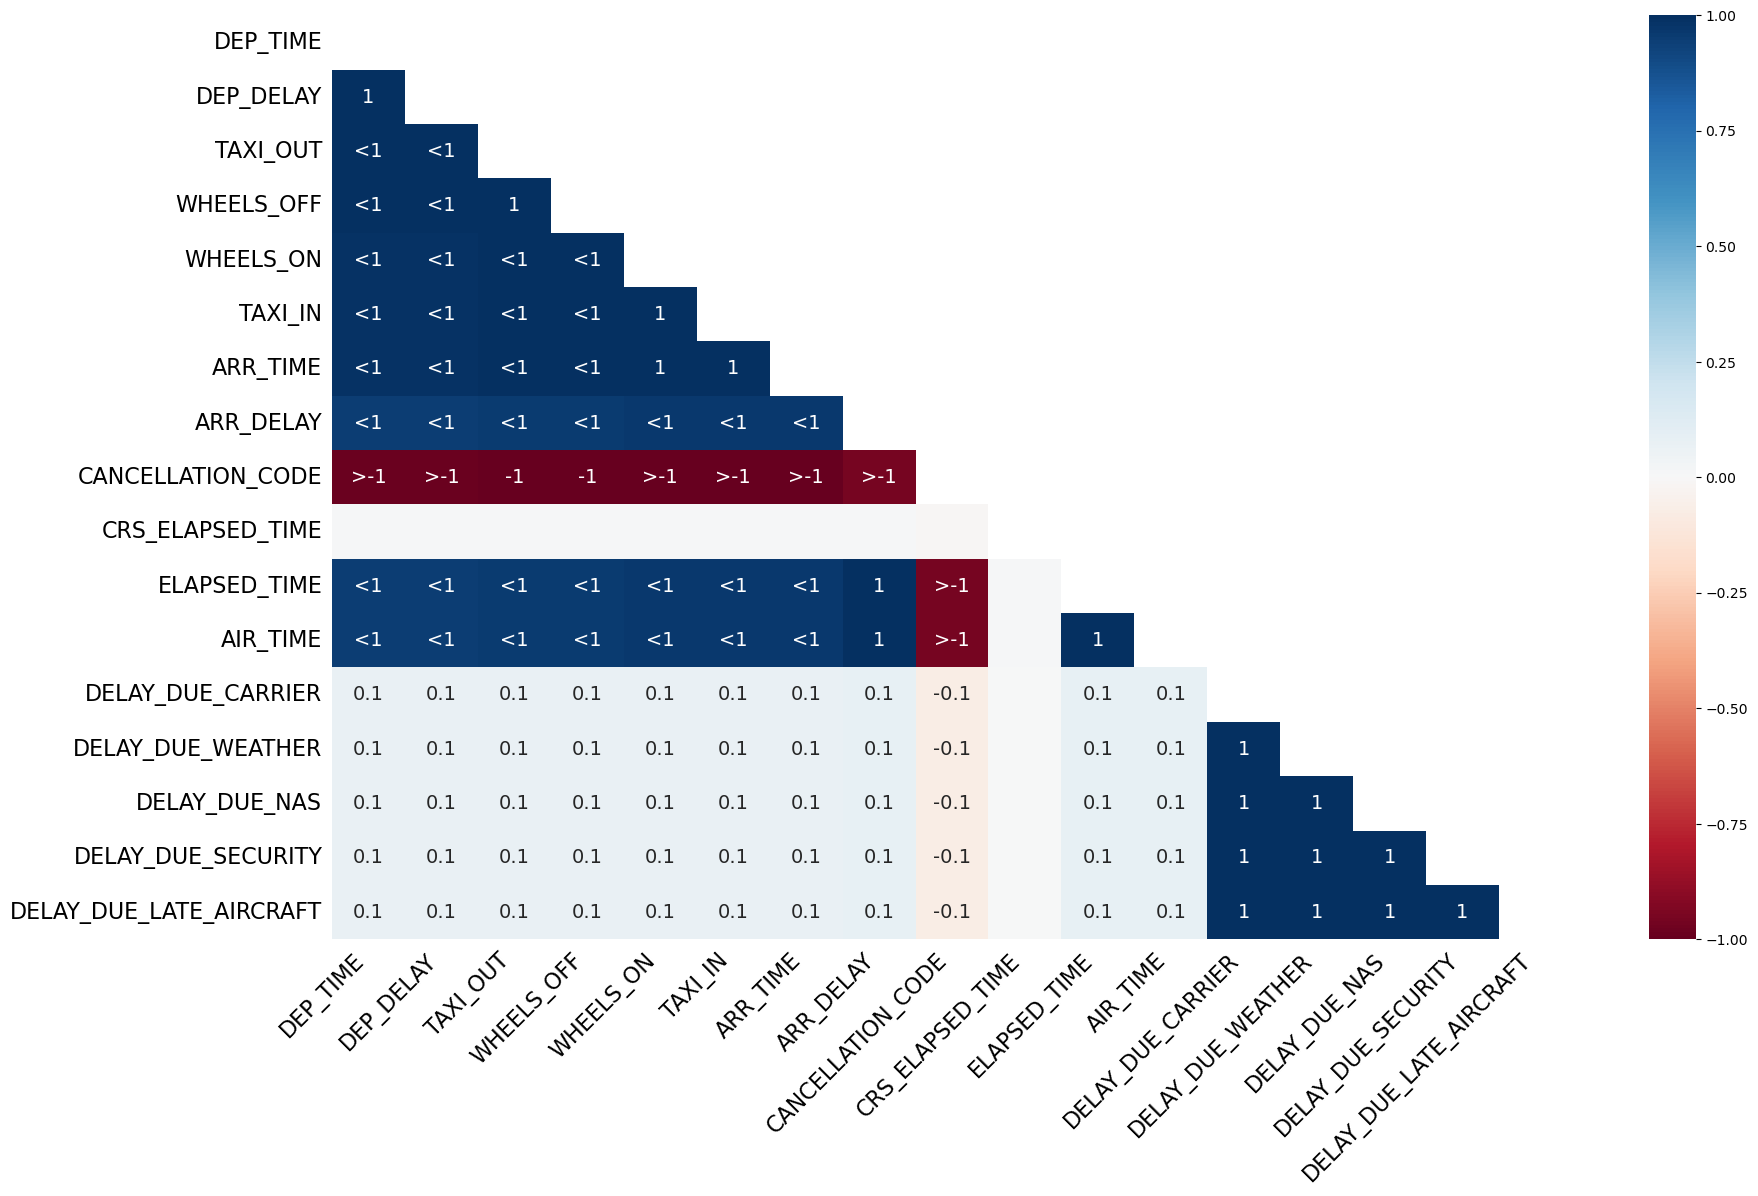

In [54]:
# ============================================
# MISSING VALUE CORRELATION
# ============================================

msno.heatmap(df)
plt.show()

In [55]:
# ============================================
# CANCELLED FLIGHT ANALYSIS
# ============================================

cancelled_flights = df[df["CANCELLED"] == 1]

print("Cancelled flights:", cancelled_flights.shape[0])

cancelled_flights.head()

Cancelled flights: 79140


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
14,2020-04-07,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,687,SJC,"San Jose, CA",LAX,"Los Angeles, CA",2155,NaN,NaN,NaN,NaN,NaN,NaN,2315,NaN,NaN,1,D,0,80.0,NaN,NaN,308.0,NaN,NaN,NaN,NaN,NaN
45,2022-01-02,Republic Airline,Republic Airline: YX,YX,20452,3467,ORD,"Chicago, IL",DCA,"Washington, DC",1935,NaN,NaN,NaN,NaN,NaN,NaN,2241,NaN,NaN,1,B,0,126.0,NaN,NaN,612.0,NaN,NaN,NaN,NaN,NaN
80,2020-04-20,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,246,BNA,"Nashville, TN",ATL,"Atlanta, GA",1055,NaN,NaN,NaN,NaN,NaN,NaN,1300,NaN,NaN,1,D,0,65.0,NaN,NaN,214.0,NaN,NaN,NaN,NaN,NaN
191,2021-12-31,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,1097,IAD,"Washington, DC",LAX,"Los Angeles, CA",1720,NaN,NaN,NaN,NaN,NaN,NaN,2024,NaN,NaN,1,A,0,364.0,NaN,NaN,2288.0,NaN,NaN,NaN,NaN,NaN
236,2020-04-14,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,446,LAS,"Las Vegas, NV",HOU,"Houston, TX",500,NaN,NaN,NaN,NaN,NaN,NaN,955,NaN,NaN,1,D,0,175.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN


In [56]:
# ============================================
# GROUP BY CANCELLED
# ============================================

df.groupby("CANCELLED").mean(numeric_only=True)

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
CANCELLED,,,,,,,,,,,,,,,,,,,,,,
0,19976.516163,2508.278620,1326.115716,1329.686939,10.095731,16.642458,1352.339024,1462.499569,7.678982,1490.000492,1466.511162,4.260858,0.002416,142.457606,136.620541,112.31084,811.085393,24.759086,3.98526,13.164728,0.145931,25.471282
1,19968.098105,2631.739512,1361.986404,1500.190164,64.000668,21.778443,1544.440120,NaN,NaN,1511.235241,NaN,NaN,0.000000,135.564871,NaN,NaN,745.738868,NaN,NaN,NaN,NaN,NaN


In [57]:
delay_columns = [
"DELAY_DUE_CARRIER",
"DELAY_DUE_WEATHER",
"DELAY_DUE_NAS",
"DELAY_DUE_SECURITY",
"DELAY_DUE_LATE_AIRCRAFT"
]

df[delay_columns].isnull().mean()*100

DELAY_DUE_CARRIER          82.204567
DELAY_DUE_WEATHER          82.204567
DELAY_DUE_NAS              82.204567
DELAY_DUE_SECURITY         82.204567
DELAY_DUE_LATE_AIRCRAFT    82.204567
dtype: float64

In [58]:
df["ARR_DELAY"].describe()

count    2.913802e+06
mean     4.260858e+00
std      5.117482e+01
min     -9.600000e+01
25%     -1.600000e+01
50%     -7.000000e+00
75%      7.000000e+00
max      2.934000e+03
Name: ARR_DELAY, dtype: float64

In [61]:
# ============================================
# HANDLE CANCELLATION CODE MISSING VALUES
# ============================================

# Add new category for non-cancelled flights
df["CANCELLATION_CODE"] = df["CANCELLATION_CODE"].cat.add_categories("None")

# Fill missing values
df["CANCELLATION_CODE"] = df["CANCELLATION_CODE"].fillna("None")

print("CANCELLATION_CODE missing values handled")

CANCELLATION_CODE missing values handled


In [62]:
# ============================================
# FILL DELAY CAUSE COLUMNS
# ============================================

delay_columns = [
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT"
]

df[delay_columns] = df[delay_columns].fillna(0)

print("Delay cause columns filled with 0")

Delay cause columns filled with 0


In [63]:
# ============================================
# CHECK MISSING VALUES AFTER CLEANING
# ============================================

print("Missing Values After Cleaning:")

print(df.isnull().sum().sort_values(ascending=False))

Missing Values After Cleaning:
AIR_TIME                   86198
ARR_DELAY                  86198
ELAPSED_TIME               86198
TAXI_IN                    79944
WHEELS_ON                  79944
ARR_TIME                   79942
TAXI_OUT                   78806
WHEELS_OFF                 78806
DEP_DELAY                  77644
DEP_TIME                   77615
CRS_ELAPSED_TIME              14
DISTANCE                       0
DELAY_DUE_CARRIER              0
DELAY_DUE_WEATHER              0
DELAY_DUE_NAS                  0
DIVERTED                       0
DELAY_DUE_SECURITY             0
CANCELLATION_CODE              0
CANCELLED                      0
FL_DATE                        0
CRS_ARR_TIME                   0
AIRLINE                        0
CRS_DEP_TIME                   0
DEST_CITY                      0
DEST                           0
ORIGIN_CITY                    0
ORIGIN                         0
FL_NUMBER                      0
DOT_CODE                       0
AIRLINE_CODE

In [64]:
# ============================================
# CHECK CANCELLATION DISTRIBUTION
# ============================================

print(df["CANCELLATION_CODE"].value_counts())

CANCELLATION_CODE
None    2920860
B         28772
D         24417
A         19476
C          6475
Name: count, dtype: int64


In [65]:
# ============================================
# FIX CRS_ELAPSED_TIME MISSING VALUES
# ============================================

median_duration = df["CRS_ELAPSED_TIME"].median()

df["CRS_ELAPSED_TIME"] = df["CRS_ELAPSED_TIME"].fillna(median_duration)

print("CRS_ELAPSED_TIME missing values fixed")

CRS_ELAPSED_TIME missing values fixed


In [66]:
# ============================================
# FINAL MISSING VALUE CHECK
# ============================================

print(df.isnull().sum().sort_values(ascending=False))

AIR_TIME                   86198
ARR_DELAY                  86198
ELAPSED_TIME               86198
TAXI_IN                    79944
WHEELS_ON                  79944
ARR_TIME                   79942
TAXI_OUT                   78806
WHEELS_OFF                 78806
DEP_DELAY                  77644
DEP_TIME                   77615
DISTANCE                       0
DELAY_DUE_CARRIER              0
DELAY_DUE_WEATHER              0
DELAY_DUE_NAS                  0
DIVERTED                       0
DELAY_DUE_SECURITY             0
CANCELLATION_CODE              0
CANCELLED                      0
CRS_ELAPSED_TIME               0
FL_DATE                        0
CRS_ARR_TIME                   0
AIRLINE                        0
CRS_DEP_TIME                   0
DEST_CITY                      0
DEST                           0
ORIGIN_CITY                    0
ORIGIN                         0
FL_NUMBER                      0
DOT_CODE                       0
AIRLINE_CODE                   0
AIRLINE_DO

In [67]:
# ============================================
# CHECK DIVERTED FLIGHTS
# ============================================

print(df["DIVERTED"].value_counts())

DIVERTED
0    2992944
1       7056
Name: count, dtype: int64


In [68]:
# ============================================
# SAVE FINAL CLEAN DATASET
# ============================================

df.to_csv("data/processed/flights_final_cleaned.csv", index=False)

print("Final cleaned dataset saved successfully")

Final cleaned dataset saved successfully


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float64       
 13  TAXI_OUT                 float64       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float64       
 17  CRS_ARR_TIME             in

In [70]:
# ============================================
# CREATE MONTH FEATURE
# ============================================

df["MONTH"] = df["FL_DATE"].dt.month

print(df["MONTH"].head())

0     1
1    11
2     7
3     3
4     2
Name: MONTH, dtype: int32


In [ ]:
df.groupby("MONTH")["ARR_DELAY"].mean()

# This shows monthly delay trends.

MONTH
1      2.190728
2      3.712646
3      2.255956
4      3.539976
5      3.359411
6     10.061753
7      9.491415
8      6.453106
9     -0.512181
10     1.424036
11     0.164154
12     6.672484
Name: ARR_DELAY, dtype: float64

In [72]:
# ============================================
# CREATE DAY OF WEEK
# ============================================

df["DAY_OF_WEEK"] = df["FL_DATE"].dt.day_name()

print(df["DAY_OF_WEEK"].value_counts())

DAY_OF_WEEK
Thursday     446925
Monday       446600
Friday       446292
Sunday       436561
Wednesday    422837
Tuesday      416562
Saturday     384223
Name: count, dtype: int64


# This allows analysis like:

busiest weekday

weekend delays

# — Create Departure Hour

Flight time is stored like:

1345 = 13:45

We extract the hour.

In [73]:
# ============================================
# CREATE DEPARTURE HOUR
# ============================================

df["DEP_HOUR"] = (df["CRS_DEP_TIME"] // 100)

print(df["DEP_HOUR"].head())

0    11
1    21
2     9
3    16
4    18
Name: DEP_HOUR, dtype: int64


# — Create Route Feature

Route combines origin and destination.

In [75]:
# ============================================
# CREATE ROUTE FEATURE
# ============================================

df["ROUTE"] = df["ORIGIN"].astype(str) + "-" + df["DEST"].astype(str)

print(df["ROUTE"].head())

0    FLL-EWR
1    MSP-SEA
2    DEN-MSP
3    MSP-SFO
4    MCO-DFW
Name: ROUTE, dtype: object


Optional Optimization 

Since ROUTE will repeat many times, we should convert it back to category to save memory.

-- This is important because airline datasets contain thousands of repeated routes.

In [76]:
# ============================================
# OPTIMIZE ROUTE COLUMN
# ============================================

df["ROUTE"] = df["ROUTE"].astype("category")

print("Route feature created and optimized")

Route feature created and optimized


In [77]:
# ============================================
# CHECK TOP ROUTES
# ============================================

print(df["ROUTE"].value_counts().head(10))

ROUTE
SFO-LAX    5358
LAX-SFO    5212
LGA-ORD    4735
OGG-HNL    4656
ORD-LGA    4634
LAX-LAS    4627
HNL-OGG    4554
LAS-LAX    4550
LAX-JFK    4403
JFK-LAX    4305
Name: count, dtype: int64


In [78]:
# ============================================
# CREATE WEEKEND INDICATOR
# ============================================

df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin(["Saturday", "Sunday"])

print(df["IS_WEEKEND"].value_counts())

IS_WEEKEND
False    2179216
True      820784
Name: count, dtype: int64


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 37 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float64       
 13  TAXI_OUT                 float64       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float64       
 17  CRS_ARR_TIME             in

# One Optimization Remaining

Column:

DAY_OF_WEEK → object

This should be category.

Why?

Because it has only 7 possible values.

In [80]:
# ============================================
# OPTIMIZE DAY_OF_WEEK COLUMN
# ============================================

df["DAY_OF_WEEK"] = df["DAY_OF_WEEK"].astype("category")

print("DAY_OF_WEEK optimized")

DAY_OF_WEEK optimized


In [81]:
# ============================================
# CHECK DATASET STRUCTURE
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 37 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   FL_DATE                  datetime64[ns]
 1   AIRLINE                  category      
 2   AIRLINE_DOT              category      
 3   AIRLINE_CODE             category      
 4   DOT_CODE                 int64         
 5   FL_NUMBER                int64         
 6   ORIGIN                   category      
 7   ORIGIN_CITY              category      
 8   DEST                     category      
 9   DEST_CITY                category      
 10  CRS_DEP_TIME             int64         
 11  DEP_TIME                 float64       
 12  DEP_DELAY                float64       
 13  TAXI_OUT                 float64       
 14  WHEELS_OFF               float64       
 15  WHEELS_ON                float64       
 16  TAXI_IN                  float64       
 17  CRS_ARR_TIME             in

In [82]:
# ============================================
# CREATE DELAY CATEGORY
# ============================================

def delay_category(delay):
    
    if pd.isna(delay):
        return "Unknown"
    
    elif delay < 0:
        return "Early"
    
    elif delay <= 15:
        return "On Time"
    
    else:
        return "Delayed"

df["DELAY_CATEGORY"] = df["ARR_DELAY"].apply(delay_category)

df["DELAY_CATEGORY"] = df["DELAY_CATEGORY"].astype("category")

print(df["DELAY_CATEGORY"].value_counts())

DELAY_CATEGORY
Early      1881970
On Time     516543
Delayed     515289
Unknown      86198
Name: count, dtype: int64


In [83]:
# ============================================
# SAVE FINAL FEATURE DATASET
# ============================================

df.to_csv("data/processed/flights_feature_engineered.csv", index=False)

print("Final feature dataset saved")

Final feature dataset saved


In [ ]:
Important Note About CSV

When we reload a CSV file:

category types are lost

everything becomes object again

To fix this we reassign categorical types.

Step 7.1 — Restore Categorical Columns

In [33]:
categorical_columns = [
"AIRLINE",
"AIRLINE_CODE",
"ORIGIN",
"DEST",
"CANCELLATION_CODE"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

In [1]:
import pandas as pd
import numpy as np


DATA_PATH = r"C:\Users\Robin\OneDrive\Documents\Flight_Delay_Analytics\data\flights_sample_3m.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")

print("Shape:", df.shape)
df.head()



Dataset Loaded Successfully
Shape: (3000000, 32)


,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns


Index(['FL_DATE', 'AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE',
       'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'DELAY_DUE_CARRIER',
       'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY',
       'DELAY_DUE_LATE_AIRCRAFT'],
      dtype='object')

# Important things we learn:

- datatype of each column

- non-null counts

- memory usage

This helps detect:

  - missing values

  - incorrect data types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [6]:
df.memory_usage(deep=True).sum() / 1024**2

1990.9640283584595

In [10]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])


In [11]:
df.describe()

,FL_DATE,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3000000,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,2021-05-07 18:03:59.616002048,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
min,2019-01-01 00:00:00,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019-12-28 00:00:00,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021-06-28 00:00:00,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2022-08-02 00:00:00,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2023-08-31 00:00:00,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000
std,NaN,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892


In [12]:
df.describe(include="object")

,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,CANCELLATION_CODE
count,3000000,3000000,3000000,3000000,3000000,3000000,3000000,79140
unique,18,18,18,380,373,380,373,4
top,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,ATL,"Chicago, IL",ATL,"Chicago, IL",B
freq,576470,576470,576470,153556,157368,153569,158087,28772


In [13]:
df.duplicated().sum()

0

In [14]:
df.sample(10)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
2397585,2021-08-27,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304,4282,SLC,"Salt Lake City, UT",SGU,"St. George, UT",...,0.0,69.0,62.0,42.0,272.0,NaN,NaN,NaN,NaN,NaN
882147,2021-06-30,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,4957,RSW,"Fort Myers, FL",MDW,"Chicago, IL",...,0.0,165.0,180.0,167.0,1105.0,NaN,NaN,NaN,NaN,NaN
2930089,2020-08-09,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1402,FLL,"Fort Lauderdale, FL",ORD,"Chicago, IL",...,0.0,208.0,193.0,169.0,1182.0,NaN,NaN,NaN,NaN,NaN
2616649,2019-05-06,Frontier Airlines Inc.,Frontier Airlines Inc.: F9,F9,20436,526,DEN,"Denver, CO",BHM,"Birmingham, AL",...,0.0,167.0,147.0,127.0,1083.0,NaN,NaN,NaN,NaN,NaN
1775053,2020-01-31,Envoy Air,Envoy Air: MQ,MQ,20398,3637,LGA,"New York, NY",CHO,"Charlottesville, VA",...,0.0,96.0,76.0,56.0,305.0,NaN,NaN,NaN,NaN,NaN
1204767,2020-11-01,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,667,IAD,"Washington, DC",LAX,"Los Angeles, CA",...,0.0,343.0,321.0,304.0,2288.0,NaN,NaN,NaN,NaN,NaN
297568,2023-06-16,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2405,PHL,"Philadelphia, PA",MSP,"Minneapolis, MN",...,0.0,186.0,164.0,136.0,980.0,NaN,NaN,NaN,NaN,NaN
663459,2023-03-16,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1534,ONT,"Ontario, CA",DFW,"Dallas/Fort Worth, TX",...,0.0,173.0,167.0,139.0,1188.0,NaN,NaN,NaN,NaN,NaN
2340594,2020-02-13,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,22,CLT,"Charlotte, NC",PHX,"Phoenix, AZ",...,0.0,289.0,279.0,254.0,1773.0,3.0,0.0,0.0,0.0,52.0
1528752,2022-08-24,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1324,ORD,"Chicago, IL",FCA,"Kalispell, MT",...,0.0,215.0,200.0,184.0,1352.0,NaN,NaN,NaN,NaN,NaN


In [15]:
df[["ARR_DELAY",
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT"]].head(20)

,ARR_DELAY,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,-14.0,NaN,NaN,NaN,NaN,NaN
1,-5.0,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN
3,24.0,0.0,0.0,24.0,0.0,0.0
4,-1.0,NaN,NaN,NaN,NaN,NaN
5,141.0,141.0,0.0,0.0,0.0,0.0
6,-29.0,NaN,NaN,NaN,NaN,NaN
7,23.0,0.0,0.0,23.0,0.0,0.0
8,-11.0,NaN,NaN,NaN,NaN,NaN
9,1.0,NaN,NaN,NaN,NaN,NaN


In [16]:
df.isnull().sum().sort_values(ascending=False)

CANCELLATION_CODE          2920860
DELAY_DUE_LATE_AIRCRAFT    2466137
DELAY_DUE_SECURITY         2466137
DELAY_DUE_NAS              2466137
DELAY_DUE_WEATHER          2466137
DELAY_DUE_CARRIER          2466137
AIR_TIME                     86198
ELAPSED_TIME                 86198
ARR_DELAY                    86198
WHEELS_ON                    79944
TAXI_IN                      79944
ARR_TIME                     79942
TAXI_OUT                     78806
WHEELS_OFF                   78806
DEP_DELAY                    77644
DEP_TIME                     77615
CRS_ELAPSED_TIME                14
ORIGIN_CITY                      0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
DISTANCE                         0
ORIGIN                           0
DEST                             0
DIVERTED                         0
CANCELLED                        0
DEST_CITY                        0
CRS_ARR_TIME        


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)


<Axes: >

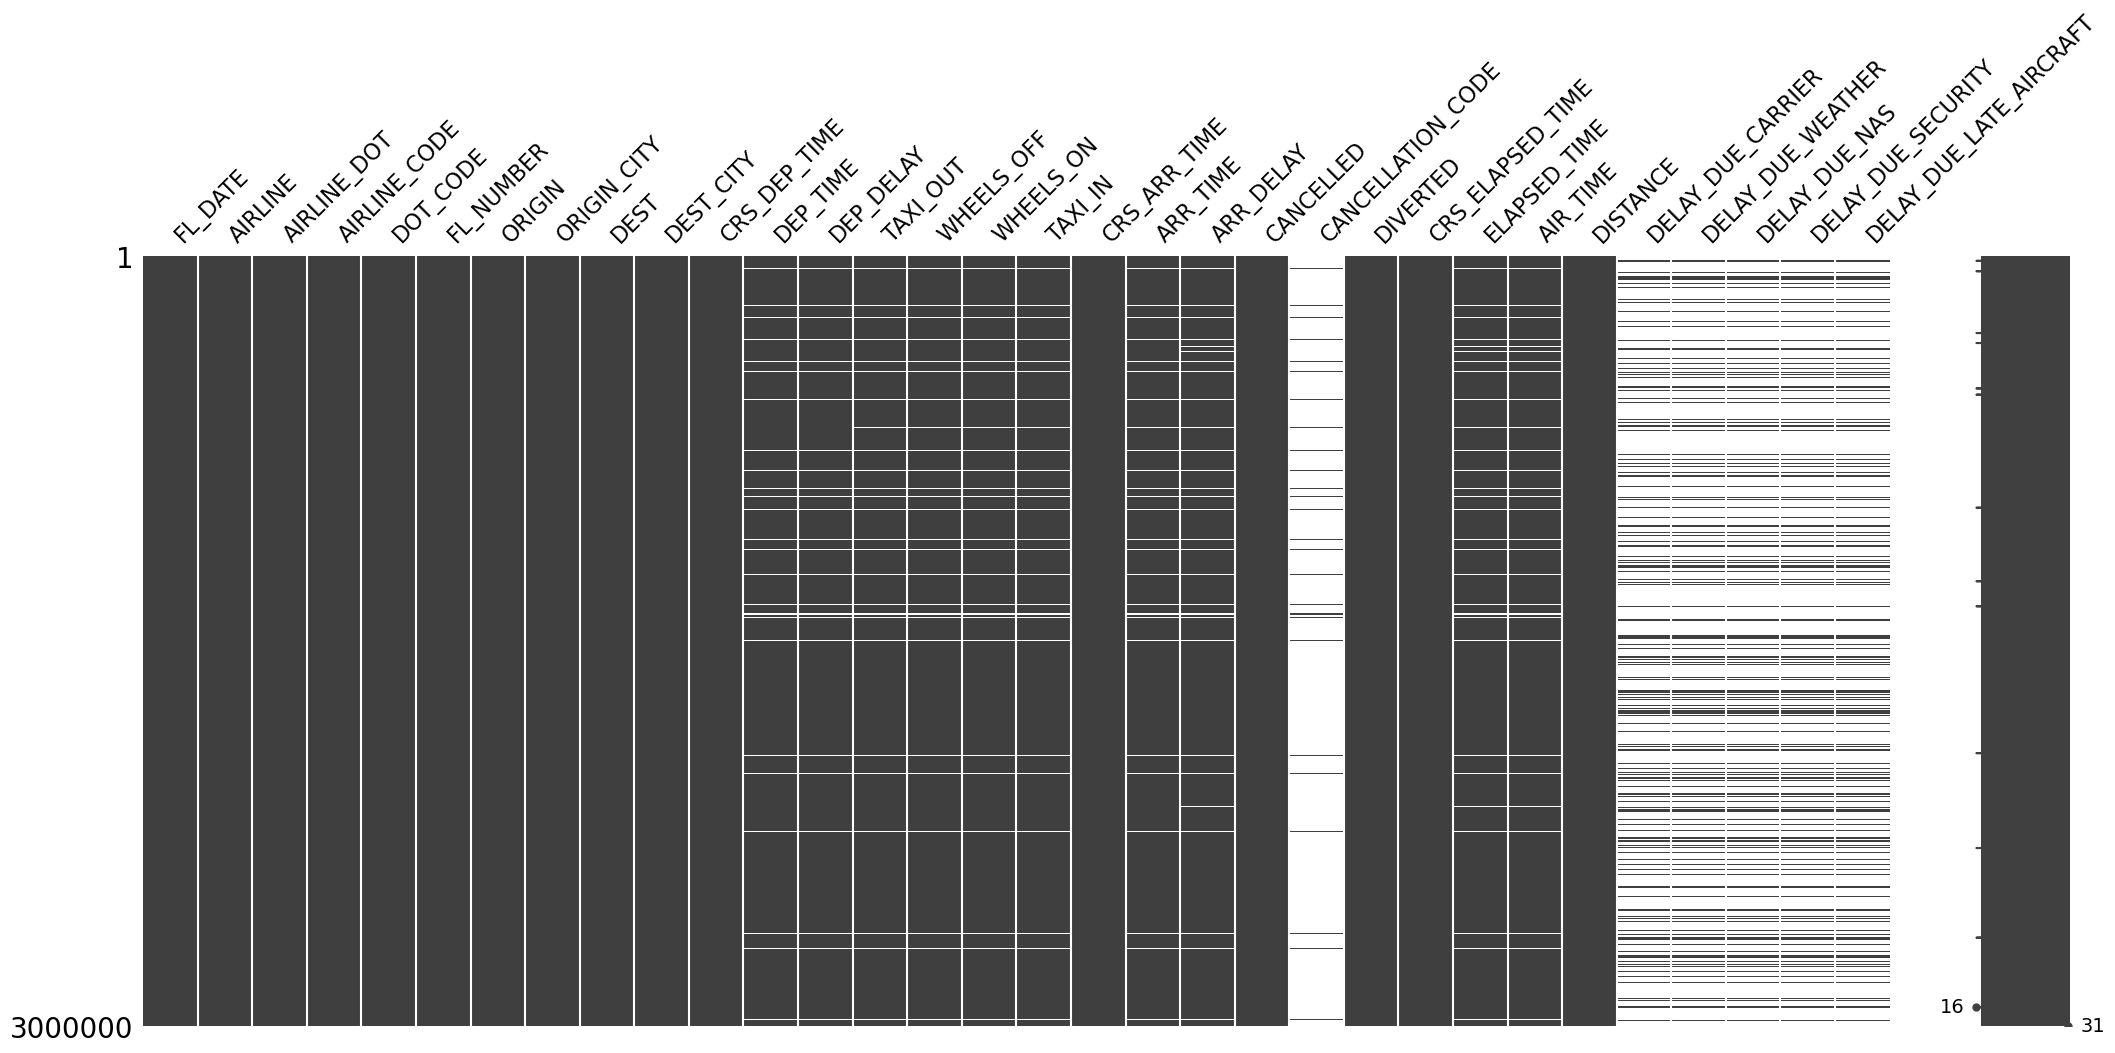

In [21]:
!pip install missingno
import missingno as msno

msno.matrix(df)

In [22]:
df[df["CANCELLED"] == 1].head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
14,2020-04-07,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,687,SJC,"San Jose, CA",LAX,"Los Angeles, CA",...,0.0,80.0,NaN,NaN,308.0,NaN,NaN,NaN,NaN,NaN
45,2022-01-02,Republic Airline,Republic Airline: YX,YX,20452,3467,ORD,"Chicago, IL",DCA,"Washington, DC",...,0.0,126.0,NaN,NaN,612.0,NaN,NaN,NaN,NaN,NaN
80,2020-04-20,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,246,BNA,"Nashville, TN",ATL,"Atlanta, GA",...,0.0,65.0,NaN,NaN,214.0,NaN,NaN,NaN,NaN,NaN
191,2021-12-31,Alaska Airlines Inc.,Alaska Airlines Inc.: AS,AS,19930,1097,IAD,"Washington, DC",LAX,"Los Angeles, CA",...,0.0,364.0,NaN,NaN,2288.0,NaN,NaN,NaN,NaN,NaN
236,2020-04-14,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,446,LAS,"Las Vegas, NV",HOU,"Houston, TX",...,0.0,175.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN


In [23]:
df.isnull().mean().sort_values(ascending=False) * 100

CANCELLATION_CODE          97.362000
DELAY_DUE_LATE_AIRCRAFT    82.204567
DELAY_DUE_SECURITY         82.204567
DELAY_DUE_NAS              82.204567
DELAY_DUE_WEATHER          82.204567
DELAY_DUE_CARRIER          82.204567
AIR_TIME                    2.873267
ELAPSED_TIME                2.873267
ARR_DELAY                   2.873267
WHEELS_ON                   2.664800
TAXI_IN                     2.664800
ARR_TIME                    2.664733
TAXI_OUT                    2.626867
WHEELS_OFF                  2.626867
DEP_DELAY                   2.588133
DEP_TIME                    2.587167
CRS_ELAPSED_TIME            0.000467
ORIGIN_CITY                 0.000000
AIRLINE_DOT                 0.000000
AIRLINE_CODE                0.000000
DOT_CODE                    0.000000
FL_NUMBER                   0.000000
DISTANCE                    0.000000
ORIGIN                      0.000000
DEST                        0.000000
DIVERTED                    0.000000
CANCELLED                   0.000000
D

In [ ]:
# ===============================
# WEEK 1 -  SCHEMA ANALYSIS
# ===============================
print("Column Data Types:")
print(df.dtypes)

print("\nColumn List:")
print(df.columns.tolist())

# Separate columns by type
categorical_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("\nCategorical Columns:", categorical_cols)
print("\nNumeric Columns:", numeric_cols)

Column Data Types:
FL_DATE                     object
AIRLINE                     object
AIRLINE_DOT                 object
AIRLINE_CODE                object
DOT_CODE                     int64
FL_NUMBER                    int64
ORIGIN                      object
ORIGIN_CITY                 object
DEST                        object
DEST_CITY                   object
CRS_DEP_TIME                 int64
DEP_TIME                   float64
DEP_DELAY                  float64
TAXI_OUT                   float64
WHEELS_OFF                 float64
WHEELS_ON                  float64
TAXI_IN                    float64
CRS_ARR_TIME                 int64
ARR_TIME                   float64
ARR_DELAY                  float64
CANCELLED                  float64
CANCELLATION_CODE           object
DIVERTED                   float64
CRS_ELAPSED_TIME           float64
ELAPSED_TIME               float64
AIR_TIME                   float64
DISTANCE                   float64
DELAY_DUE_CARRIER          float64
D

In [32]:
df.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,300000.000000,300000.000000,300000.000000,292292.000000,300000.000000,292168.000000,292168.000000,292047.000000,292047.000000,300000.000000,...,300000.000000,299999.000000,291382.000000,291382.000000,300000.000000,53521.000000,53521.000000,53521.000000,53521.000000,53521.000000
mean,19976.372630,2513.921653,1327.867817,1330.649303,10.025273,16.658039,1353.234047,1463.544056,7.688304,1491.170703,...,0.002503,142.504398,136.857781,112.523011,811.146313,25.281123,4.229424,13.158685,0.141739,25.411745
std,377.316488,1748.991071,485.717135,499.342287,49.507100,9.193365,500.888860,527.387017,6.310193,511.831883,...,0.049971,71.844714,71.981883,70.059922,590.040227,72.373268,33.590647,33.970947,2.821631,55.600368
min,19393.000000,1.000000,1.000000,1.000000,-62.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,18.000000,15.000000,8.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19790.000000,1048.000000,915.000000,917.000000,-6.000000,11.000000,932.000000,1050.000000,4.000000,1109.000000,...,0.000000,90.000000,84.000000,61.000000,379.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19930.000000,2158.000000,1320.000000,1323.000000,-2.000000,14.000000,1336.000000,1502.000000,6.000000,1518.000000,...,0.000000,125.000000,120.000000,95.000000,655.000000,4.000000,0.000000,0.000000,0.000000,0.000000
75%,20368.000000,3805.000000,1730.000000,1739.000000,6.000000,19.000000,1752.000000,1909.000000,9.000000,1920.000000,...,0.000000,173.000000,168.000000,142.000000,1047.000000,23.000000,0.000000,17.000000,0.000000,29.000000
max,20452.000000,8794.000000,2359.000000,2400.000000,2895.000000,174.000000,2400.000000,2400.000000,217.000000,2359.000000,...,1.000000,695.000000,693.000000,669.000000,5095.000000,2565.000000,1326.000000,1711.000000,221.000000,1514.000000


In [ ]:

# ===============================
# WEEK 1 - Missing Values 
# ===============================

print("Missing Values:")
print(df.isnull().sum())

# Calculate Missing Percentage
null_report = df.isnull().sum()
null_percentage = (null_report / len(df)) * 100

print("Missing Percentage:")
print(null_percentage)

Missing Values:
FL_DATE                         0
AIRLINE                         0
AIRLINE_DOT                     0
AIRLINE_CODE                    0
DOT_CODE                        0
FL_NUMBER                       0
ORIGIN                          0
ORIGIN_CITY                     0
DEST                            0
DEST_CITY                       0
CRS_DEP_TIME                    0
DEP_TIME                     7708
DEP_DELAY                       0
TAXI_OUT                     7832
WHEELS_OFF                   7832
WHEELS_ON                    7953
TAXI_IN                      7953
CRS_ARR_TIME                    0
ARR_TIME                     7952
ARR_DELAY                       0
CANCELLED                       0
CANCELLATION_CODE          292133
DIVERTED                        0
CRS_ELAPSED_TIME                1
ELAPSED_TIME                 8618
AIR_TIME                     8618
DISTANCE                        0
DELAY_DUE_CARRIER          246479
DELAY_DUE_WEATHER          24647

In [ ]:
import os

os.makedirs("reports", exist_ok=True)

# save file
null_report.to_csv("reports/null_analysis_report.csv", index=False)

print("Null report saved successfully.")

Null report saved successfully.


In [ ]:
# ===============================
# WEEK 1 -  SAMPLING
# ===============================

sample_df = df.sample(n=300000, random_state=42)

sample_df.to_csv("reports/sample_flights.csv", index=False)

print("Sample dataset saved successfully.")

Sample dataset saved successfully.


In [35]:
import pandas as pd

df = pd.read_csv("reports/sample_flights.csv")

In [39]:
df.fillna(0, inplace=True)

In [41]:
df['Month'] = pd.to_datetime(df['FL_DATE']).dt.month

In [42]:
df['Day'] = pd.to_datetime(df['FL_DATE']).dt.day_name()

In [43]:
df['Hour'] = df['DEP_TIME'] // 100

In [50]:
df['Route'] = df['ORIGIN'] + "-" + df['DEST']

print(df[['Month', 'Day', 'Hour', 'Route']].head())


   Month      Day  Hour    Route
0      5  Tuesday  15.0  MCO-JFK
1     11  Tuesday   7.0  FLL-DTW
2      6   Sunday  21.0  SMF-LAS
3      7   Sunday   5.0  OKC-DTW
4      3   Friday  20.0  FLL-SFO


In [47]:
df.to_csv("reportscleaned_flights.csv", index=False)

In [48]:
df = pd.read_csv("reportscleaned_flights.csv")

In [49]:
print("\nChecking Missing Values After Cleaning:")
print(df.isnull().sum())


Checking Missing Values After Cleaning:
FL_DATE                    0
AIRLINE                    0
AIRLINE_DOT                0
AIRLINE_CODE               0
DOT_CODE                   0
FL_NUMBER                  0
ORIGIN                     0
ORIGIN_CITY                0
DEST                       0
DEST_CITY                  0
CRS_DEP_TIME               0
DEP_TIME                   0
DEP_DELAY                  0
TAXI_OUT                   0
WHEELS_OFF                 0
WHEELS_ON                  0
TAXI_IN                    0
CRS_ARR_TIME               0
ARR_TIME                   0
ARR_DELAY                  0
CANCELLED                  0
CANCELLATION_CODE          0
DIVERTED                   0
CRS_ELAPSED_TIME           0
ELAPSED_TIME               0
AIR_TIME                   0
DISTANCE                   0
DELAY_DUE_CARRIER          0
DELAY_DUE_WEATHER          0
DELAY_DUE_NAS              0
DELAY_DUE_SECURITY         0
DELAY_DUE_LATE_AIRCRAFT    0
Month                      0
Da